# KNN Exercise

![iris](images/iris.jpg)

We are going to use the famous **iris data set** again. 

The dataset consists of four attributes, which can be used to distinguish different iris species: 
* sepal-width
* sepal-length
* petal-width 
* petal-length. 


The task is to predict the class to which these plants belong. There are three classes in the dataset: **Iris-setosa, Iris-versicolor and Iris-virginica.** 

Further details of the dataset are available here.
https://scikit-learn.org/stable/auto_examples/datasets/plot_iris_dataset.html

## Task

1. Please import and pre-process the data (as far as it's necessary). Afterwards split it in a train and test set, fit a KNN model and make predictions on the test set. The last step is to evaluate your model. Try to also scale your data and fit the model to the unscaled and scaled data. Can you see a difference in performance? 
If you can't it's because the original features are all on a very similar scale. Try multiplying one of the features by a factor of 10 and fitting the model to unscaled and scaled data. The difference should now be obvious 

2. Please also calculate the accuracy for K values of 1 to 40. In each iteration the accuracy for the predicted values of the test set is calculated and the result is appended to an error list.
The next step is to plot the accuracy values against K values.

# Task 1

Task 1: Train, Predict, and the Scaling Experiment

Your first task asks you to import the data, split it, fit a KNN model, and see what happens when you scale the data (or intentionally mess up the scale by multiplying a feature by 10).  

Step 1: Import Libraries and Load Data
First, we need to gather our tools and the data.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Load the Iris dataset as X
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

In [2]:
X.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [3]:
X.info


<bound method DataFrame.info of      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]>

In [4]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


Step 2: Train/Test Split
We need to hide some data to act as our "Real Test" later.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

Step 3: The Scaling Experiment
KNN calculates the physical distance between points. If one feature is measured in tiny decimals and another is measured in thousands, the larger numbers will completely dominate the math.

To see this in action, the exercise asks you to multiply one feature by 10. Let's multiply the sepal length (cm) by 10, completely ruining the natural scale.

In [6]:
# Intentionally messing up the scale
X_train_messy = X_train.copy()
X_test_messy = X_test.copy()
X_train_messy['sepal length (cm)'] = X_train_messy['sepal length (cm)'] * 10
X_test_messy['sepal length (cm)'] = X_test_messy['sepal length (cm)'] * 10

# Train and test on the MESSY data
knn_messy = KNeighborsClassifier(n_neighbors=5)
knn_messy.fit(X_train_messy, y_train)
y_pred_messy = knn_messy.predict(X_test_messy)

print("Accuracy on MESSY data:", accuracy_score(y_test, y_pred_messy).round(3))

Accuracy on MESSY data: 0.921


Step 4: Fixing it with StandardScaler
To fix the messy data, we use a Scaler. A Scaler squashes all features down so they share the exact same ruler (usually between -3 and 3).

In [7]:
# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on the training data, then transform both train and test
X_train_scaled = scaler.fit_transform(X_train_messy)
X_test_scaled = scaler.transform(X_test_messy)

# Train and test on the SCALED data
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = knn_scaled.predict(X_test_scaled)

print("Accuracy on SCALED data:", accuracy_score(y_test, y_pred_scaled).round(3))

Accuracy on SCALED data: 1.0


Notice how the accuracy jumps back up? That is why scaling is mandatory for KNN!

# Task 2

Task 2: Finding the Best "K" (The Loop)

How do we know if we should ask 3 neighbors, 5 neighbors, or 20 neighbors? We don't! The best way to find out is to try them all and see which one gets the highest grade on the test.  

We will use a for loop to test K values from 1 to 40, and save the accuracy of each try into a list.

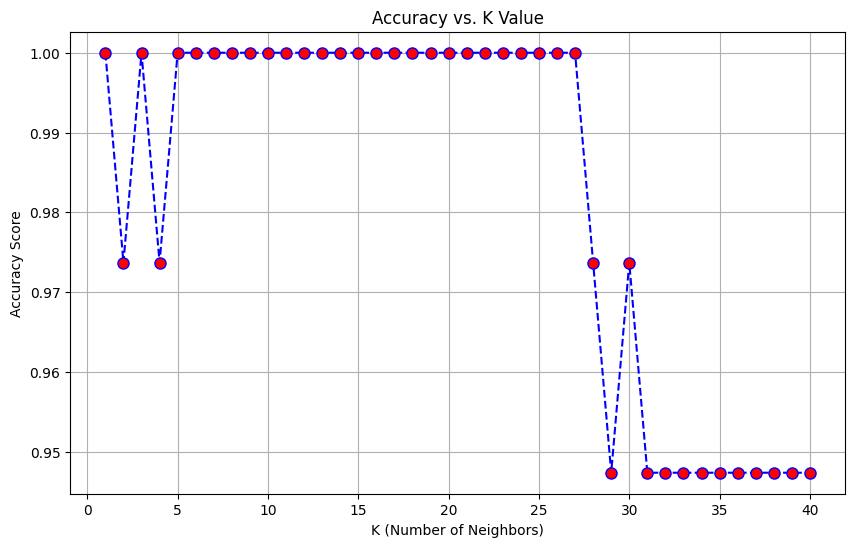

In [8]:
# Create an empty list to store our grades (accuracies)
accuracy_list = []

# Loop through numbers 1 to 40
k_values = range(1, 41)

for k in k_values:
    # 1. Create a model with 'k' neighbors
    knn = KNeighborsClassifier(n_neighbors=k)
    
    # 2. Train it on the scaled data
    knn.fit(X_train_scaled, y_train)
    
    # 3. Predict the test set
    y_pred = knn.predict(X_test_scaled)
    
    # 4. Grade it and append the score to our list
    score = accuracy_score(y_test, y_pred)
    accuracy_list.append(score)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracy_list, color='blue', linestyle='dashed', marker='o', markerfacecolor='red', markersize=8)
plt.title('Accuracy vs. K Value')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Accuracy Score')
plt.grid(True)
plt.show()

When you run this plot, look for the peak! The highest point on the graph is the best 'K' value for your model.

# Cheatsheet KNN

In [11]:
#🚀 Your Scikit-Learn Universal Cheatsheet

#Print this out or save it! You can use this exact 6-step blueprint for Almost EVERY model you build in scikit-learn (Logistic Regression, KNN, Random Forests, etc.).

#1. Split
#Python

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

#2. Scale (If necessary)
#Python

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#3. Initialize (Build the empty brain)
#Python

model = KNeighborsClassifier(n_neighbors=5) 
# OR model = LogisticRegression()

#4. Fit (Study for the test)
#Python

model.fit(X_train_scaled, y_train)

#5. Predict (Take the test)
#Python

y_pred = model.predict(X_test_scaled)

#6. Evaluate (Grade the test)
#Python

print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

1.0


NameError: name 'confusion_matrix' is not defined